<a href="https://colab.research.google.com/github/Josefina1808/tesina/blob/main/anexo_codigo_tesina.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Modelo VAR

In [ ]:
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from statsmodels.tsa.api import VAR
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [ ]:
df = pd.read_excel('series_para_VECM.xlsx', index_col='AÑO', sheet_name=3)
df_modelo = df.dropna()

In [ ]:
# --- Test ADF ---
# H0: La serie tiene raíz unitaria (es no estacionaria).
# H1: La serie es estacionaria.
# Entonces --> Rechazamos H0: ESTACIONARIA I(0) y No rechazamos H0: NO ESTACIONARIA I(1)
def adf_test(series, nombre):
    resultado = adfuller(series, autolag='AIC')
    p_value = resultado[1]
    print(f"Prueba ADF para {nombre}:")
    if p_value < 0.05:
        print(f"p-value:{p_value:.4f} => ESTACIONARIA I(0).")
    else:
        print(f"p-value:{p_value:.4f} => NO ESTACIONARIA I(1)")
    print()

print("2. Resultados del Test de Dickey-Fuller:")
for col in df_modelo.columns:
    adf_test(df_modelo[col], col)

In [ ]:
# --- Test de Cointegración de Johansen ---

df_clean = df_modelo[['dif_log_pbi', 'dif_log_ipc', 'tasa_informalidad']]

print("--- TEST DE JOHANSEN ---")
johansen_test = coint_johansen(df_clean, det_order=1, k_ar_diff=1)
trazas = johansen_test.lr1
criticos_5 = johansen_test.cvt[:, 1]

for i in range(len(trazas)):
    if trazas[i] > criticos_5[i]:
        print(f"r = {i}: Traza ({trazas[i]:.2f}) > Crítico ({criticos_5[i]:.2f}) => Hay cointegración.")
    else:
        print(f"r = {i}: Traza ({trazas[i]:.2f}) < Crítico ({criticos_5[i]:.2f}) => NO hay cointegración.")

In [ ]:
#### MODELO ####

df_var_2 = df_modelo[['dif_log_pbi', 'dif_log_ipc']].dropna()
modelo_var = VAR(df_var_2)
resultados_var = modelo_var.fit(maxlags=2, ic='aic')

print("\n--- RESUMEN DEL MODELO VAR ---")
print(resultados_var.summary())

# EXTRACCIÓN MATRIZ DE COVARIANZAS
matriz_cov = resultados_var.sigma_u
print("\n--- MATRIZ COVARIANZAS RESIDUOS ---")
print(matriz_cov)

In [ ]:
#Guardo moedlo
df_coeficientes = resultados_var.params
df_coeficientes.to_csv('var_coeficientes.csv')

# Guardo matriz de covarianzas de los residuos
df_covarianzas = pd.DataFrame(resultados_var.sigma_u, index=['dif_log_pbi', 'dif_log_ipc'], columns=['dif_log_pbi', 'dif_log_ipc'])
df_covarianzas.to_csv('var_covarianzas.csv')

### 2. Shocks

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
# Extracción datos
df_cov = pd.read_csv('var_covarianzas.csv', index_col=0)
matriz_cov = df_cov.values

#Matriz Cholesky
L = np.linalg.cholesky(matriz_cov)

In [ ]:
num_simulaciones = 20000
horizonte_anios = 15 # 2026 a 2040

shocks_pbi_total = np.zeros((num_simulaciones, horizonte_anios))
shocks_ipc_total = np.zeros((num_simulaciones, horizonte_anios))
shocks_infor_total = np.zeros((num_simulaciones, horizonte_anios))

# Supuesto de elasticidad (exógeno): Por cada 1% que cae el PBI,
elasticidad_informalidad = -0.217027377

In [ ]:
np.random.seed(42) # Para reproducibilidad
for i in range(num_simulaciones):

    Z = np.random.normal(loc=0.0, scale=1.0, size=(horizonte_anios, 2))

    # Multiplicamos por la transpuesta de L para correlacionar los shocks
    shocks_correlacionados = Z @ L.T

    shock_pbi = shocks_correlacionados[:, 0]
    shock_ipc = shocks_correlacionados[:, 1]
    shock_infor = shock_pbi * elasticidad_informalidad

    # Guardo
    shocks_pbi_total[i, :] = shock_pbi
    shocks_ipc_total[i, :] = shock_ipc
    shocks_infor_total[i, :] = shock_infor

In [ ]:
columnas_anios = [f'Ano_{i+1}' for i in range(horizonte_anios)]

df_shocks_pbi = pd.DataFrame(shocks_pbi_total, columns=columnas_anios)
df_shocks_ipc = pd.DataFrame(shocks_ipc_total, columns=columnas_anios)
df_shocks_infor = pd.DataFrame(shocks_infor_total, columns=columnas_anios)

# Exportar a CSV
df_shocks_pbi.to_csv('simulacion_20000_shocks_pbi_heavy.csv', index=False)
df_shocks_ipc.to_csv('simulacion_20000_shocks_ipc_heavy.csv', index=False)
df_shocks_infor.to_csv('simulacion_20000_shocks_infor_heavy.csv', index=False)

### 3. Simulacion NDC

In [ ]:
import pandas as pd
import numpy as np
from tqdm import tqdm

#### data

In [ ]:
df_constantes = pd.read_excel('bases_sim.xlsx', sheet_name='constantes')
CONSTANTES = df_constantes.set_index(df_constantes.columns[0])[df_constantes.columns[1]].to_dict()

df_pob = pd.read_excel('bases_sim.xlsx', sheet_name='proyeccion_pob')
df_pob = df_pob.set_index(df_pob.columns[0])

df_ratios = pd.read_excel('bases_sim.xlsx', sheet_name='historial_ratios')
historial_RS_base = df_ratios.iloc[:, 1].tolist()
historial_RL_base = df_ratios.iloc[:, 2].tolist()

df_probas = pd.read_excel('bases_sim.xlsx', sheet_name='tabla_mort')
filtered_df = df_probas[(df_probas.iloc[:, 0] >= 50) & (df_probas.iloc[:, 0] <= 64)]
vector_px_completo = filtered_df.iloc[:, 3].tolist()

df_shocks = pd.read_csv('simulacion_20000_shocks_infor.csv')
matriz_shocks = df_shocks.values

#### funciones

In [ ]:
def proyectar_fondo_nocional(fondo_acumulado_t_menos_1, aporte_mensual, tasa_nocional_t, prob_supervivencia_total, anio_actual, anio_inicio=2026):
    """
    Proyecta el capital nocional desde el año t hasta el retiro,
    ajustando el horizonte de probabilidades según el año de simulación.

    Parámetros:
    - fondo_acumulado_t_menos_1 (float): Capital real acumulado hasta el año anterior.
    - aporte_mensual (float): El aporte mensual en el año t.
    - tasa_nocional_t (float): La tasa nocional del año en curso.
    - prob_supervivencia_total (list/array): vector probas de sobrevivir un año
    - anio_actual (int): año que está corriendo en el bucle de la simulación
    - anio_inicio (int): primer año de la simulación
    """

    offset = anio_actual - anio_inicio

    px_restantes = prob_supervivencia_total[offset:]

    aporte_anual = aporte_mensual * 13

    fondo_proyectado = fondo_acumulado_t_menos_1
    historial_proyeccion = []

    for px in px_restantes:
        cap_saldo = fondo_proyectado * (1 + tasa_nocional_t)
        cap_aporte = aporte_anual * (1 + tasa_nocional_t)

        fondo_fin_anio = cap_saldo + cap_aporte
        fondo_proyectado = fondo_fin_anio / px

        historial_proyeccion.append(fondo_proyectado)

    return fondo_proyectado, historial_proyeccion

In [ ]:
def calcular_jubilacion_ndc(capital_acumulado, divisor_esperanza_vida):

    jubilacion_anual = capital_acumulado / divisor_esperanza_vida
    jubilacion_mensual = jubilacion_anual / 12

    return jubilacion_anual, jubilacion_mensual

In [ ]:
# ==============================================================================
# FUNCIÓN DE SIMULACIÓN PARA UN ESCENARIO
# ==============================================================================

def simular_escenario_alt(id_escenario, vector_shock_infor):
    """
    Corre la simulación completa (2026-2040) para un vector de shocks específico.
    """
        # --- RESETEO VARIABLES INICIALES ---
    informalidad_actual = CONSTANTES['informalidad_0']
    fondo_reserva_actual = CONSTANTES['fondo_reserva_0']
    i_nocional_actual = CONSTANTES['i_nocional_0']

    hist_RS = historial_RS_base.copy()
    hist_RL = historial_RL_base.copy()
    hist_RR = []
    hist_PBI = []
    hist_informalidad = []

    fondo_real_actual = CONSTANTES['fondo_individuo_2025']

    contador_ABM = 0
    years_alive = 0

    resultados_sim = []

    # BUCLE
    for t, year in enumerate(range(2026, 2041)):

        # SHOCKS
        shock_infor = vector_shock_infor[t] / 100
        informalidad_actual = max(0, min(1, informalidad_actual + shock_infor))
        hist_informalidad.append(informalidad_actual)

        shock_pbi = vector_shock_pbi[t] / 100
        hist_PBI.append(shock_pbi)

        # DEMOGRAFÍA
        total_pob = df_pob.loc['total_pob', year]
        PEA = df_pob.loc['activos', year]
        pasivos = df_pob.loc['pasivos', year]

        aportantes = PEA * CONSTANTES['prop_trabajadores'] * (1 - informalidad_actual)
        jubilados = pasivos * CONSTANTES['alcance']
        pensionados_menores = total_pob * CONSTANTES['prop_pensionados'] * CONSTANTES['prop_pensionados_menores']

        # Aportante promedio
        fondo_esperado_retiro, historial_proyeccion = proyectar_fondo_nocional(
            fondo_acumulado_t_menos_1 = fondo_real_actual,
            aporte_mensual = CONSTANTES['aporte_NDC_mensual'],
            tasa_nocional_t = i_nocional_actual,
            prob_supervivencia_total = vector_px_completo,
            anio_actual = year
        )

        jub_anual_NDC, jub_mensual_NDC = calcular_jubilacion_ndc(fondo_esperado_retiro, CONSTANTES['a_jub_extensible'])
        replacement_rate = jub_mensual_NDC / CONSTANTES['sueldo_neto']
        hist_RR.append(replacement_rate)

        aportes_totales = aportantes * CONSTANTES['aporte_NDC_mensual'] * 13

        # Beneficios: discriminado
        factor_jub = (CONSTANTES['propor_jub_morat']*(1+CONSTANTES['desc_jub_morat']) + (1 - CONSTANTES['propor_jub_morat']))
        factor_pen = (CONSTANTES['propor_pen_morat']*(1+CONSTANTES['desc_pen_morat']) + (1 - CONSTANTES['propor_pen_morat']))

        beneficios_jub = jub_anual_NDC * jubilados * factor_jub
        beneficios_pen = jub_anual_NDC * 0.70 * pensionados_menores * factor_pen

        beneficios_totales = beneficios_jub + beneficios_pen
        resultado_inicial = aportes_totales - beneficios_totales

        # FONDO DE RESERVA
        pago_fondo = resultado_inicial
        fondo_reserva_actual = fondo_reserva_actual * (1 + CONSTANTES['i_fondo']) + pago_fondo

        # QUIEBRA DEL SISTEMA
        if fondo_reserva_actual < 0:
            print(f"⚠️ El sistema quebró en el año {year} (Escenario {id_escenario})")
            break

        years_alive += 1

        # Ratios y ABM
        activo_aportes = aportes_totales * CONSTANTES['TD']
        VP_pensiones = CONSTANTES['a_pensionados'] * beneficios_pen
        VP_jubilaciones = CONSTANTES['a_jubilados'] * beneficios_jub
        NPW_sistema = aportes_totales * (65-CONSTANTES['edad_prom_aportante'])

        ratio_solvencia = (fondo_reserva_actual + activo_aportes) / (VP_pensiones + VP_jubilaciones + NPW_sistema)
        ratio_liquidez = aportes_totales / beneficios_totales

        # Promedios ratio ult 5 años --> para ABM
        hist_RS.append(ratio_solvencia)
        hist_RL.append(ratio_liquidez)
        RS_mean = np.mean(hist_RS[-5:])
        RL_mean = np.mean(hist_RL[-5:])

        ABM = 0.6 * RL_mean + 0.4 * RS_mean

        fondo_real_actual = historial_proyeccion[0]

        if ABM < 1:
            i_nocional_ajust = i_nocional_actual * ABM
            contador_ABM += 1
        else:
            i_nocional_ajust = i_nocional_actual

        i_nocional_actual = i_nocional_ajust

        # REGISTRO ANUAL
        resultados_sim.append({
            'Year': year, 'total_pob': total_pob, 'PEA': PEA, 'pasivos': pasivos,
            'informalidad': informalidad_actual, 'aportantes': aportantes,
            'jubilados': jubilados, 'pensionados_menores': pensionados_menores,
            'aportes_totales': aportes_totales, 'beneficios_jub': beneficios_jub,
            'beneficios_pen': beneficios_pen, 'beneficios_totales': beneficios_totales,
            'resultado_inicial': resultado_inicial, 'pago_fondo': pago_fondo,
            'fondo_reserva': fondo_reserva_actual, 'activo_aportes': activo_aportes,
            'VP_pensiones': VP_pensiones, 'VP_jubilaciones': VP_jubilaciones, 'NPW_sistema': NPW_sistema,
            'ratio_solvencia': ratio_solvencia, 'ratio_liquidez': ratio_liquidez,
            'RS_mean': RS_mean, 'RL_mean': RL_mean, 'ABM': ABM,
            'i_nocional_ajust': i_nocional_ajust, 'replacement_rate': replacement_rate
        })

    df_resultados = pd.DataFrame(resultados_sim)
    RS_15yrs_mean = np.mean(hist_RS)
    RL_15yrs_mean = np.mean(hist_RL)
    RR_15yrs_mean = np.mean(hist_RR)
    PBI_15yrs_mean = np.mean(hist_PBI)
    PBI_15yrs_std = np.std(hist_PBI)
    informalidad_15yrs_mean = np.mean(hist_informalidad)
    informalidad_15yrs_std = np.std(hist_informalidad)

    return df_resultados, contador_ABM, years_alive, RS_15yrs_mean, RL_15yrs_mean, RR_15yrs_mean, informalidad_15yrs_mean, informalidad_15yrs_std, PBI_15yrs_mean, PBI_15yrs_std

In [ ]:
# ==============================================================================
# FUNCIÓN DE SIMULACIÓN PARA UN ESCENARIO sin ABM
# ==============================================================================

def simular_escenario_alt_not_abm(id_escenario, vector_shock_infor):

    informalidad_actual = CONSTANTES['informalidad_0']
    fondo_reserva_actual = CONSTANTES['fondo_reserva_0']
    i_nocional_actual = CONSTANTES['i_nocional_0']

    hist_RS = historial_RS_base.copy()
    hist_RL = historial_RL_base.copy()
    hist_RR = []

    fondo_real_actual = CONSTANTES['fondo_individuo_2025']
    years_alive = 0
    resultados_sim = []

    for t, year in enumerate(range(2026, 2041)):

        shock_infor = vector_shock_infor[t] / 100
        informalidad_actual = max(0, min(1, informalidad_actual + shock_infor))

        total_pob = df_pob.loc['total_pob', year]
        PEA = df_pob.loc['activos', year]
        pasivos = df_pob.loc['pasivos', year]

        aportantes = PEA * CONSTANTES['prop_trabajadores'] * (1 - informalidad_actual)
        jubilados = pasivos * CONSTANTES['alcance']
        pensionados_menores = total_pob * CONSTANTES['prop_pensionados'] * CONSTANTES['prop_pensionados_menores']

        fondo_esperado_retiro, historial_proyeccion = proyectar_fondo_nocional(
            fondo_acumulado_t_menos_1 = fondo_real_actual,
            aporte_mensual = CONSTANTES['aporte_NDC_mensual'],
            tasa_nocional_t = i_nocional_actual,
            prob_supervivencia_total = vector_px_completo,
            anio_actual = year
        )

        jub_anual_NDC, jub_mensual_NDC = calcular_jubilacion_ndc(fondo_esperado_retiro, CONSTANTES['a_jub_extensible'])
        replacement_rate = jub_mensual_NDC / CONSTANTES['sueldo_neto']
        hist_RR.append(replacement_rate)

        aportes_totales = aportantes * CONSTANTES['aporte_NDC_mensual'] * 13

        factor_jub = (CONSTANTES['propor_jub_morat']*(1+CONSTANTES['desc_jub_morat']) + (1 - CONSTANTES['propor_jub_morat']))
        factor_pen = (CONSTANTES['propor_pen_morat']*(1+CONSTANTES['desc_pen_morat']) + (1 - CONSTANTES['propor_pen_morat']))

        beneficios_jub = jub_anual_NDC * jubilados * factor_jub
        beneficios_pen = jub_anual_NDC * 0.70 * pensionados_menores * factor_pen

        beneficios_totales = beneficios_jub + beneficios_pen
        resultado_inicial = aportes_totales - beneficios_totales

        pago_fondo = resultado_inicial
        fondo_reserva_actual = fondo_reserva_actual * (1 + CONSTANTES['i_fondo']) + pago_fondo

        if fondo_reserva_actual < 0:
            print(f"⚠️ El sistema quebró en el año {year} (Escenario {id_escenario})")
            break

        years_alive += 1

        activo_aportes = aportes_totales * CONSTANTES['TD']
        VP_pensiones = CONSTANTES['a_pensionados'] * beneficios_pen
        VP_jubilaciones = CONSTANTES['a_jubilados'] * beneficios_jub
        NPW_sistema = aportes_totales * (65-CONSTANTES['edad_prom_aportante'])

        ratio_solvencia = (fondo_reserva_actual + activo_aportes) / (VP_pensiones + VP_jubilaciones + NPW_sistema)
        ratio_liquidez = aportes_totales / beneficios_totales

        hist_RS.append(ratio_solvencia)
        hist_RL.append(ratio_liquidez)
        RS_mean = np.mean(hist_RS[-5:])
        RL_mean = np.mean(hist_RL[-5:])

        ABM = 0.6 * RL_mean + 0.4 * RS_mean

        fondo_real_actual = historial_proyeccion[0]

        resultados_sim.append({
            'Year': year, 'total_pob': total_pob, 'PEA': PEA, 'pasivos': pasivos,
            'informalidad': informalidad_actual, 'aportantes': aportantes,
            'jubilados': jubilados, 'pensionados_menores': pensionados_menores,
            'aportes_totales': aportes_totales, 'beneficios_jub': beneficios_jub,
            'beneficios_pen': beneficios_pen, 'beneficios_totales': beneficios_totales,
            'resultado_inicial': resultado_inicial, 'pago_fondo': pago_fondo,
            'fondo_reserva': fondo_reserva_actual, 'activo_aportes': activo_aportes,
            'VP_pensiones': VP_pensiones, 'VP_jubilaciones': VP_jubilaciones, 'NPW_sistema': NPW_sistema,
            'ratio_solvencia': ratio_solvencia, 'ratio_liquidez': ratio_liquidez,
            'RS_mean': RS_mean, 'RL_mean': RL_mean, 'replacement_rate': replacement_rate
        })

    df_resultados = pd.DataFrame(resultados_sim)
    RS_15yrs_mean = np.mean(hist_RS)
    RL_15yrs_mean = np.mean(hist_RL)
    RR_15yrs_mean = np.mean(hist_RR)

    return df_resultados, years_alive, RS_15yrs_mean, RL_15yrs_mean, RR_15yrs_mean

#### simulación

In [ ]:
###### CON AMB ######
total_escenarios = len(matriz_shocks)
print(f"Iniciando simulación Monte Carlo para {total_escenarios} escenarios...")

for i, vector_shock in enumerate(tqdm(matriz_shocks, desc="Simulando")):

    id_escenario = i + 1

    df_anual, activaciones_abm, vida_sistema, RS_mean, RL_mean, RR_mean, infor_mean, infor_std, pbi_mean, pbi_std = simular_escenario_alt(
        id_escenario=id_escenario,
        vector_shock_infor=vector_shock
    )

    quebro = 1 if vida_sistema < 15 else 0

    fondo_final = df_anual['fondo_reserva'].iloc[-1]

    resultados_montecarlo.append({
        'id_escenario': id_escenario,
        'years_alive': vida_sistema,
        'activaciones_abm': activaciones_abm,
        'fondo_final': fondo_final,
        'quiebra': quebro,
        'RS_mean': RS_mean,
        'RL_mean': RL_mean,
        'RR_mean': RR_mean,
        'pbi_mean': pbi_mean,
        'pbi_std': pbi_std,
        'infor_mean': informalidad_mean,
        'infor_std': informalidad_std,
    })

# ==============================================================================
# RESULTADOS FINALES
# ==============================================================================

df_resultados_finales = pd.DataFrame(resultados_montecarlo)

df_resultados_finales.to_csv('Resultados_MonteCarlo_Resumen_alt_1.csv', index=False)

probabilidad_ruina = df_resultados_finales['quiebra'].mean() * 100
promedio_vida = df_resultados_finales['years_alive'].mean()
promedio_activacion_abm = df_resultados_finales['activaciones_abm'].mean()

print("\n" + "="*50)
print("🎯 RESULTADOS 🎯")
print("="*50)
print(f"Probabilidad de Ruina del Sistema: {probabilidad_ruina:.2f}%")
print(f"Vida media del sistema:            {promedio_vida:.2f} años")
print(f"Promedio de activaciones del ABM:  {promedio_activacion_abm:.2f} veces por escenario")

In [ ]:
###### SIN AMB ######
total_escenarios = len(matriz_shocks)
print(f"Iniciando simulación Monte Carlo para {total_escenarios} escenarios...")

for i, vector_shock in enumerate(tqdm(matriz_shocks, desc="Simulando")):

    id_escenario = i + 1

    df_anual, vida_sistema, RS_mean, RL_mean, RR_mean = simular_escenario_alt_not_abm(
        id_escenario=id_escenario,
        vector_shock_infor=vector_shock
    )

    quebro = 1 if vida_sistema < 15 else 0

    fondo_final = df_anual['fondo_reserva'].iloc[-1]

    resultados_montecarlo.append({
        'id_escenario': id_escenario,
        'years_alive': vida_sistema,
        'fondo_final': fondo_final,
        'quiebra': quebro,
        'RS_mean': RS_mean,
        'RL_mean': RL_mean,
        'RR_mean': RR_mean
    })

# ==============================================================================
# RESULTADOS FINALES
# ==============================================================================

df_resultados_finales = pd.DataFrame(resultados_montecarlo)

df_resultados_finales.to_csv('Resultados_MonteCarlo_Resumen_alt_NOT_1.csv', index=False)

# Calculamos algunas estadísticas actuariales clave
probabilidad_ruina = df_resultados_finales['quiebra'].mean() * 100
promedio_vida = df_resultados_finales['years_alive'].mean()

print("\n" + "="*50)
print("🎯 RESULTADOS 🎯")
print("="*50)
print(f"Probabilidad de Ruina del Sistema: {probabilidad_ruina:.2f}%")
print(f"Vida media del sistema:            {promedio_vida:.2f} años")

### 4. Análisis resultados

#### data y librerias

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import pearsonr
from scipy import stats

In [ ]:
df_abm = pd.read_csv('Resultados_MonteCarlo_Resumen_alt_1.csv')
df_no_abm = pd.read_csv('Resultados_MonteCarlo_Resumen_alt_NOT_1.csv')

#### graficos y métricas

##### ruina

In [ ]:
ruin_prob_abm = df_abm['quiebra'].mean()
ruin_prob_no_abm = df_no_abm['quiebra'].mean()

print(f"Probilidad de Ruina with ABM: {ruin_prob_abm:.3%}")
print(f"Probilidad de Ruina without ABM: {ruin_prob_no_abm:.3%}")

percentage_reduction = ((ruin_prob_no_abm - ruin_prob_abm) / ruin_prob_no_abm) * 100
print(f"Reducción porcentual en la probabilidad de ruina con ABM: {percentage_reduction:.2f}%")

##### RR vs ABM

In [ ]:
print("--- Estadísticas RR ---")
print(f"Sin ABM - Media: {df_no_abm['RR_mean'].mean():,.4f} | Desviación Estándar: {df_no_abm['RR_mean'].std():,.4f}")
print(f"Con ABM - Media: {df_abm['RR_mean'].mean():,.4f} | Desviación Estándar: {df_abm['RR_mean'].std():,.5f}")

In [ ]:
#Boxplot de RR_mean: ABM vs NOT ABM
df_abm['Mecanismo'] = 'Con ABM'
df_no_abm['Mecanismo'] = 'Sin ABM'
col_rr = 'RR_mean'

df_plot = pd.concat([df_no_abm[[col_rr, 'Mecanismo']], df_abm[[col_rr, 'Mecanismo']]])

plt.style.use('ggplot')
fig, ax = plt.subplots(figsize=(8, 6))
colors = {'Sin ABM': '#e74c3c', 'Con ABM': '#3498db'}

sns.boxplot(
    data=df_plot,
    x='Mecanismo',
    y=col_rr,
    palette=colors,
    width=0.4,
    linewidth=1.2,
    fliersize=2,
    ax=ax
)

ax.set_title('Impacto del Mecanismo Automático (ABM) en la Tasa de Reemplazo',
             fontsize=14, pad=15, fontweight='bold', color='#333333')
ax.set_ylabel('Tasa de Reemplazo Media', fontsize=12, color='#555555')
ax.set_xlabel('')

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))

ax.set_facecolor('#f0f0f0')
ax.grid(color='white', linestyle='-', linewidth=0.8, alpha=0.7)

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.savefig('Boxplot_RR_Real.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
#BOXPLOT solo de ABM
df_abm['Mecanismo'] = 'Con ABM'
col_rr = 'RR_mean'

plt.style.use('ggplot')
fig, ax = plt.subplots(figsize=(8, 6))

colors = {'Con ABM': '#3498db'}

sns.boxplot(
    data=df_abm,
    y=col_rr,
    color=colors['Con ABM'],
    width=0.4,
    linewidth=1.2,
    fliersize=2,
    ax=ax
)

q1_abm = df_abm[col_rr].quantile(0.25)
q3_abm = df_abm[col_rr].quantile(0.75)
iqr_abm = q3_abm - q1_abm
lower_whisker_abm = q1_abm - 1.5 * iqr_abm
outliers_abm_lower = df_abm[df_abm[col_rr] < lower_whisker_abm][col_rr]

if not outliers_abm_lower.empty:
    furthest_outlier_lower = outliers_abm_lower.min()

    ax.annotate(
        f'RR mínimo: {furthest_outlier_lower:.2%}',
        xy=(0, furthest_outlier_lower),
        xytext=(-0.4, furthest_outlier_lower),
        textcoords='data',
        ha='left',
        va='center',
        color='red',
        fontsize=10,
        bbox=dict(boxstyle='round,pad=0.3', fc='yellow', alpha=0.5, ec='none'),
        arrowprops=dict(arrowstyle='-', connectionstyle='arc3,rad=-0.2', color='red')
    )

max_rr_value = df_abm[col_rr].max()
ax.annotate(
    f'RR máximo: {max_rr_value:.2%}',
    xy=(0, max_rr_value),
    xytext=(0.2, max_rr_value),
    textcoords='data',
    ha='left',
    va='center',
    color='green',
    fontsize=10,
    bbox=dict(boxstyle='round,pad=0.3', fc='lightgreen', alpha=0.5, ec='none'),
    arrowprops=dict(arrowstyle='-', connectionstyle='arc3,rad=0.2', color='green')
)

ax.set_title('Tasa de Reemplazo sistema Con ABM', # Updated title
             fontsize=14, pad=15, fontweight='bold', color='#333333')
ax.set_ylabel('Tasa de Reemplazo Media', fontsize=12, color='#555555')
ax.set_xlabel('')

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))

ax.set_facecolor('#f0f0f0')
ax.grid(color='white', linestyle='-', linewidth=0.8, alpha=0.7)

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.savefig('Boxplot_RR_Con_ABM.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Correlación entre activaciones_abm y RR_mean

col_activaciones = 'activaciones_abm'
col_rr = 'RR_mean'
corr, p_value = pearsonr(df_abm[col_activaciones], df_abm[col_rr])

print(f"Correlación de Pearson: {corr:.3f} (P-valor: {p_value:.3e})")

plt.style.use('ggplot')
fig, ax = plt.subplots(figsize=(9, 6))
sns.regplot(
    data=df_abm,
    x=col_activaciones,
    y=col_rr,
    ax=ax,
    scatter_kws={'alpha': 0.05, 'color': '#3498db', 's': 15},
    line_kws={'color': '#e74c3c', 'linewidth': 2}
)
ax.set_title(f'Trade-off del Sistema: Activaciones del ABM vs. Tasa de Reemplazo\n(Correlación de Pearson: r = {corr:.2f})',
             fontsize=14, pad=15, fontweight='bold', color='#333333')
ax.set_xlabel('Cantidad de Años con Ajuste Automático (0 a 15 años)', fontsize=12, color='#555555')
ax.set_ylabel('Tasa de Reemplazo Media', fontsize=12, color='#555555')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
ax.set_facecolor('#f0f0f0')
ax.grid(color='white', linestyle='-', linewidth=0.8, alpha=0.7)

for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.savefig('Correlacion_ABM_vs_RR.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Distribución RR con ABM
plt.style.use('ggplot')
colors = {'ABM': '#3498db', 'NO_ABM': '#e74c3c'}

fig, ax = plt.subplots(figsize=(10, 6))
ax.set_facecolor('#f0f0f0')

sns.kdeplot(data=df_abm, x='RR_mean', color=colors['ABM'], fill=True, alpha=0.3, label='Con ABM', ax=ax)

ax.set_title('Distribución Tasa Reemplazo Media con ABM', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Tasa de Reemplazo', fontsize=12)
ax.set_ylabel('Densidad', fontsize=12)
ax.legend(frameon=True, facecolor='white')
ax.grid(color='white', linestyle='-', linewidth=0.7)

plt.tight_layout()
plt.savefig('Distribucion_RR.png', dpi=300)
plt.show()

##### dinámica ABM

In [ ]:
# Gráfico de Torta de Activaciones
abm_activado = (df_abm['activaciones_abm'] > 0).sum()
abm_no_activado = (df_abm['activaciones_abm'] == 0).sum()

totales = [abm_activado, abm_no_activado]
etiquetas = ['Activado al menos una vez', 'No Activado']
colores = ['#3498db', '#e74c3c']

plt.style.use('ggplot')
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_facecolor('#f0f0f0')

wedges, texts, autotexts = ax.pie(totales,
                                  labels=etiquetas,
                                  colors=colores,
                                  autopct='%1.1f%%',
                                  startangle=90,
                                  pctdistance=0.85,
                                  wedgeprops=dict(width=0.3, edgecolor='white'))

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(14)
    autotext.set_weight('bold')

for text in texts:
    text.set_fontsize(12)
    text.set_color('#333333')

ax.set_title('Análisis de Activaciones ABM',
             fontsize=16, pad=20, fontweight='bold', color='#333333')

ax.axis('equal')


plt.tight_layout()
plt.savefig('Porcentaje_ABM_Activado.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# DE AQUELLOS QUE ACTIVARON ABM CUÁNTOS QUEBRARON
df_abm_activated = df_abm[df_abm['activaciones_abm'] > 0]

ruined_activated = df_abm_activated['quiebra'].sum()
survived_activated = len(df_abm_activated) - ruined_activated

totales_activados = [ruined_activated, survived_activated]
etiquetas_activados = ['Quebraron', 'Sobrevivieron']
colores_activados = ['#e74c3c', '#3498db']

plt.style.use('ggplot')
fig, ax = plt.subplots(figsize=(4, 4))
ax.set_facecolor('#f0f0f0')

wedges, texts, autotexts = ax.pie(totales_activados,
                                  labels=etiquetas_activados,
                                  colors=colores_activados,
                                  autopct='%1.1f%%',
                                  startangle=90,
                                  pctdistance=0.85,
                                  wedgeprops=dict(width=0.3, edgecolor='white'))

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(12)
    autotext.set_weight('bold')

for text in texts:
    text.set_fontsize(10)
    text.set_color('#333333')

ax.set_title('Escenarios con ABM Activado:\nQuebraron vs. Sobrevivieron',
             fontsize=14, pad=20, fontweight='bold', color='#333333')

ax.axis('equal')

plt.tight_layout()
plt.savefig('Donut_ABM_Activado_Quebraron_Sobrevivieron.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
#Scatter Plot de activaciones_abm vs. RS_mean
col_activaciones = 'activaciones_abm'
col_rs_mean = 'RS_mean'

plt.style.use('ggplot')
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_facecolor('#f0f0f0')

sns.regplot(
    data=df_abm,
    x=col_activaciones,
    y=col_rs_mean,
    ax=ax,
    scatter_kws={'alpha': 0.1, 'color': '#3498db', 's': 20},
    line_kws={'color': '#e74c3c', 'linewidth': 2}
)

ax.axhline(y=1.0, color='gray', linestyle=':', linewidth=1.5, label='RS = 1')

ax.set_title('Relación entre Activaciones ABM y Ratio Solvencia',
             fontsize=14, pad=15, fontweight='bold', color='#333333')
ax.set_xlabel('Cantidad de Activaciones ABM', fontsize=12, color='#555555')
ax.set_ylabel('Ratio Solvencia (RS_mean)', fontsize=12, color='#555555')

ax.grid(color='white', linestyle='-', linewidth=0.8, alpha=0.7)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.legend()

plt.tight_layout()
plt.savefig('Scatter_ActivacionesABM_vs_RSMean.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Mean, std, mode para grupo ABM>0
df_abm_activados = df_abm[df_abm['activaciones_abm'] > 0]['activaciones_abm']

moda_activaciones_abm_activados = df_abm_activados.mode()
mean_activaciones_abm_activados = df_abm_activados.mean()
std_activaciones_abm_activados = df_abm_activados.std()

print(f"Moda activaciones para escenarios que activaron el ABM: {moda_activaciones_abm_activados[0]}")
print(f"Media activaciones para escenarios que activaron el ABM: {mean_activaciones_abm_activados:.2f}")
print(f"Desvio estándar activaciones para escenarios que activaron el ABM: {std_activaciones_abm_activados:.2f}")

In [ ]:
# Mean, std, mode para grupo ABM total
print(f"Media de Activaciones: {df_abm['activaciones_abm'].mean():.2f}")
print(f"Desviación Estándar de Activaciones: {df_abm['activaciones_abm'].std():.2f}")
moda_activaciones = df_abm['activaciones_abm'].mode()
print(f"Moda de Activaciones: {moda_activaciones[0]}")

##### Quebrados vs NO quebrados

###### Quebrados

In [ ]:
df_quebrados = df_abm[df_abm['quiebra'] == 1]['activaciones_abm']

moda_activaciones_quebrados = df_quebrados.mode()
mean_activaciones_quebrados = df_quebrados.mean()
std_activaciones_quebrados = df_quebrados.std()
max_activaciones_quebrados = df_quebrados.max()
min_activaciones_quebrados = df_quebrados.min()

print(f"Moda de las activaciones ABM para escenarios que quebraron es: {moda_activaciones_quebrados[0]}")
print(f"Media de las activaciones ABM para escenarios que quebraron es: {mean_activaciones_quebrados:.2f}")
print(f"Desvio estándar de las activaciones ABM para escenarios que quebraron es: {std_activaciones_quebrados:.2f}")
print(f"Máximo de las activaciones ABM para escenarios que quebraron es: {max_activaciones_quebrados}")
print(f"Mínimo de las activaciones ABM para escenarios que quebraron es: {min_activaciones_quebrados}")

La moda de las activaciones ABM para escenarios que quebraron es: 9
La media de las activaciones ABM para escenarios que quebraron es: 9.20
La desviación estándar de las activaciones ABM para escenarios que quebraron es: 0.45
El máximo de las activaciones ABM para escenarios que quebraron es: 10
El mínimo de las activaciones ABM para escenarios que quebraron es: 9


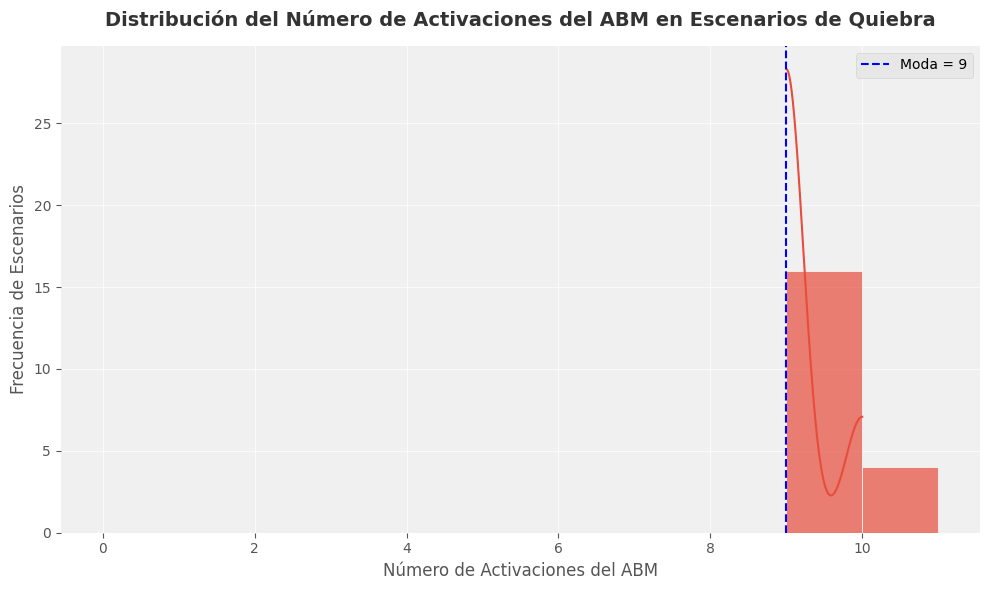

In [ ]:
# Distribucion_Activaciones_Quebrados
df_quebrados_activaciones = df_abm[df_abm['quiebra'] == 1]['activaciones_abm']

plt.style.use('ggplot')
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_facecolor('#f0f0f0')

sns.histplot(
    data=df_quebrados_activaciones,
    bins=range(0, int(df_quebrados_activaciones.max()) + 2),
    kde=True,
    color='#e74c3c',
    edgecolor='white',
    linewidth=0.5,
    alpha=0.7,
    ax=ax
)

ax.axvline(x=9, color='blue', linestyle='--', linewidth=1.5, label='Moda = 9')

ax.set_title('Distribución del Número de Activaciones del ABM en Escenarios de Quiebra',
             fontsize=14, pad=15, fontweight='bold', color='#333333')
ax.set_xlabel('Número de Activaciones del ABM', fontsize=12, color='#555555')
ax.set_ylabel('Frecuencia de Escenarios', fontsize=12, color='#555555')

ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

ax.grid(color='white', linestyle='-', linewidth=0.8, alpha=0.7)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.legend()

plt.tight_layout()
plt.savefig('Distribucion_Activaciones_Quebrados.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
df_quebrados_metrics = df_abm[df_abm['quiebra'] == 1]

mean_infor_quiebra = df_quebrados_metrics['infor_mean'].mean()
std_infor_quiebra = df_quebrados_metrics['infor_mean'].std()
LL = mean_infor_quiebra - std_infor_quiebra
UL = mean_infor_quiebra + std_infor_quiebra

n_quiebra = len(df_quebrados_metrics)
if n_quiebra > 1:
    se_infor_quiebra = std_infor_quiebra / (n_quiebra**0.5)

    t_critical = stats.t.ppf(0.975, df=n_quiebra - 1)
    margin_of_error = t_critical * se_infor_quiebra
    conf_interval_lower = mean_infor_quiebra - margin_of_error
    conf_interval_upper = mean_infor_quiebra + margin_of_error

    print(f"--- Estadísticas de Informalidad (infor_mean) para Escenarios de Quiebra ---")
    print(f"Media de informalidad: {mean_infor_quiebra:.4f}")
    print(f"Desviación estándar de informalidad: {std_infor_quiebra:.4f}")
    print(f"Intervalo de una desviación estándar: ({LL:.4f}, {UL:.4f})")
    print(f"Intervalo de Confianza del 95% para la Media: ({conf_interval_lower:.4f}, {conf_interval_upper:.4f})")
else:
    print(f"No hay suficientes datos en escenarios de quiebra para calcular el intervalo estadístico (n={n_quiebra}).")

mean_pbi_quiebra = df_quebrados_metrics['pbi_mean'].mean()
std_pbi_quiebra = df_quebrados_metrics['pbi_mean'].std()
LL = mean_pbi_quiebra - std_pbi_quiebra
UL = mean_pbi_quiebra + std_pbi_quiebra

print(f"--- ---------------------------------------------------------- ---")
print(f"--- Estadísticas de PBI para Escenarios de NO Quiebra ---")
print(f"Media de Variación PBI: {mean_pbi_quiebra:.4f}")
print(f"Desviación estándar de Variación PBI: {std_pbi_quiebra:.4f}")
print(f"Intervalo de una desviación estándar: ({LL:.4f}, {UL:.4f})")

--- Estadísticas de Informalidad (infor_mean) para Escenarios de Quiebra ---
Media de informalidad: 0.6791
Desviación estándar de informalidad: 0.0048
Intervalo de una desviación estándar: (0.6743, 0.6839)
Intervalo de Confianza del 95% para la Media: (0.6769, 0.6813)
--- ---------------------------------------------------------- ---
--- Estadísticas de PBI para Escenarios de NO Quiebra ---
Media de Variación PBI: 0.4216
Desviación estándar de Variación PBI: 0.5051
Intervalo de una desviación estándar: (-0.0835, 0.9267)


In [ ]:
metrics = ['RR_mean', 'RS_mean', 'RL_mean']

print("--- Ratios quebrados ---")
for col in metrics:
    mean_val = df_quebrados_metrics[col].mean()
    std_val = df_quebrados_metrics[col].std()
    print(f"  {col}:")
    print(f"    Media: {mean_val:.4f}")
    print(f"    Desviación Estándar: {std_val:.4f}")

--- Estadísticas para escenarios que quebraron ---
  RR_mean:
    Media: 0.7730
    Desviación Estándar: 0.0030
  RS_mean:
    Media: 0.9008
    Desviación Estándar: 0.0075
  RL_mean:
    Media: 0.7837
    Desviación Estándar: 0.0084


###### No quebrados

In [ ]:
df_NOT_quebrados = df_abm[df_abm['quiebra'] == 0]['activaciones_abm']

moda_activaciones_NOT_quebrados = df_NOT_quebrados.mode()
mean_activaciones_NOT_quebrados = df_NOT_quebrados.mean()
std_activaciones_NOT_quebrados = df_NOT_quebrados.std()
max_activaciones_NOT_quebrados = df_NOT_quebrados.max()
min_activaciones_NOT_quebrados = df_NOT_quebrados.min()

print(f"La moda de las activaciones ABM para escenarios que NO quebraron es: {moda_activaciones_NOT_quebrados[0]}")
print(f"La media de las activaciones ABM para escenarios que NO quebraron es: {mean_activaciones_NOT_quebrados:.2f}")
print(f"La desviación estándar de las activaciones ABM para escenarios que NO quebraron es: {std_activaciones_NOT_quebrados:.2f}")
print(f"El máximo de las activaciones ABM para escenarios que NO quebraron es: {max_activaciones_NOT_quebrados}")
print(f"El mínimo de las activaciones ABM para escenarios que NO quebraron es: {min_activaciones_NOT_quebrados}")

# Filtro escenarios que NO quebraron
df_NOT_quebrados_metrics = df_abm[df_abm['quiebra'] == 0]

mean_infor_NOT_quiebra = df_NOT_quebrados_metrics['infor_mean'].mean()
std_infor_NOT_quiebra = df_NOT_quebrados_metrics['infor_mean'].std()
LL = mean_infor_NOT_quiebra - std_infor_NOT_quiebra
UL = mean_infor_NOT_quiebra + std_infor_NOT_quiebra

print(f"--- ---------------------------------------------------------- ---")
print(f"--- Estadísticas de Informalidad para Escenarios de NO Quiebra ---")
print(f"Media de informalidad: {mean_infor_NOT_quiebra:.4f}")
print(f"Desviación estándar de informalidad: {std_infor_NOT_quiebra:.4f}")
print(f"Intervalo de una desviación estándar: ({LL:.4f}, {UL:.4f})")

mean_pbi_NOT_quiebra = df_NOT_quebrados_metrics['pbi_mean'].mean()
std_pbi_NOT_quiebra = df_NOT_quebrados_metrics['pbi_mean'].std()
LL = mean_pbi_NOT_quiebra - std_pbi_NOT_quiebra
UL = mean_pbi_NOT_quiebra + std_pbi_NOT_quiebra

print(f"--- ---------------------------------------------------------- ---")
print(f"--- Estadísticas de PBI para Escenarios de NO Quiebra ---")
print(f"Media de Var PBI: {mean_pbi_NOT_quiebra:.4f}")
print(f"Desviación estándar de Var PBI: {std_pbi_NOT_quiebra:.4f}")
print(f"Intervalo de una desviación estándar: ({LL:.4f}, {UL:.4f})")

La moda de las activaciones ABM para escenarios que NO quebraron es: 0
La media de las activaciones ABM para escenarios que NO quebraron es: 1.08
La desviación estándar de las activaciones ABM para escenarios que NO quebraron es: 2.34
El máximo de las activaciones ABM para escenarios que NO quebraron es: 11
El mínimo de las activaciones ABM para escenarios que NO quebraron es: 0
--- ---------------------------------------------------------- ---
--- Estadísticas de Informalidad para Escenarios de NO Quiebra ---
Media de informalidad: 0.4169
Desviación estándar de informalidad: 0.0694
Intervalo de una desviación estándar: (0.3475, 0.4863)
--- ---------------------------------------------------------- ---
--- Estadísticas de PBI para Escenarios de NO Quiebra ---
Media de Var PBI: 0.5346
Desviación estándar de Var PBI: 0.5353
Intervalo de una desviación estándar: (-0.0007, 1.0699)


In [ ]:
metrics = ['RR_mean', 'RS_mean', 'RL_mean']

print("--- Ratios NO quiebra  ---")
for col in metrics:
    mean_val = df_NOT_quebrados_metrics[col].mean()
    std_val = df_NOT_quebrados_metrics[col].std()
    print(f"  {col}:")
    print(f"    Media: {mean_val:.4f}")
    print(f"    Desviación Estándar: {std_val:.4f}")

--- Estadísticas para escenarios NO quiebra  ---
  RR_mean:
    Media: 0.7902
    Desviación Estándar: 0.0016
  RS_mean:
    Media: 1.0692
    Desviación Estándar: 0.0346
  RL_mean:
    Media: 1.1832
    Desviación Estándar: 0.1144


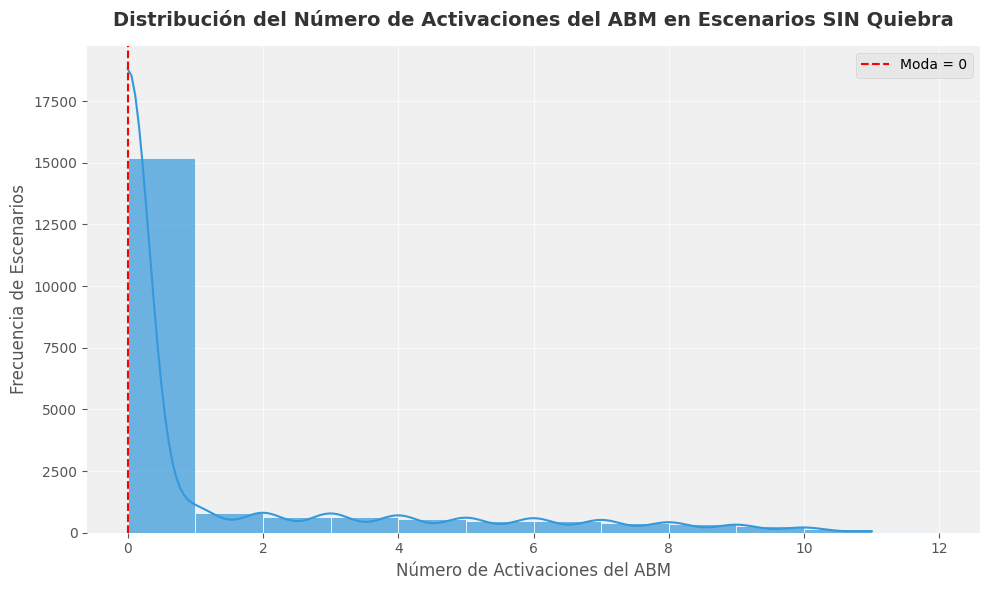

In [ ]:
# Distribucion_Activaciones_No_Quebrados
df_no_quebrados_activaciones = df_abm[df_abm['quiebra'] == 0]['activaciones_abm']

plt.style.use('ggplot')
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_facecolor('#f0f0f0')

sns.histplot(
    data=df_no_quebrados_activaciones,
    bins=range(0, int(df_no_quebrados_activaciones.max()) + 2),
    kde=True,
    color='#3498db',
    edgecolor='white',
    linewidth=0.5,
    alpha=0.7,
    ax=ax
)

ax.axvline(x=0, color='red', linestyle='--', linewidth=1.5, label='Moda = 0')

ax.set_title('Distribución del Número de Activaciones del ABM en Escenarios SIN Quiebra',
             fontsize=14, pad=15, fontweight='bold', color='#333333')
ax.set_xlabel('Número de Activaciones del ABM', fontsize=12, color='#555555')
ax.set_ylabel('Frecuencia de Escenarios', fontsize=12, color='#555555')

ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

ax.grid(color='white', linestyle='-', linewidth=0.8, alpha=0.7)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.legend()

plt.tight_layout()
plt.savefig('Distribucion_Activaciones_No_Quebrados.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
count_activacion_11 = (df_no_quebrados_activaciones == 11).sum()
print(f"Número de casos donde 'activaciones_abm' es 11 en escenarios sin quiebra: {count_activacion_11}")

Número de casos donde 'activaciones_abm' es 11 en escenarios sin quiebra: 47


In [ ]:
count_activacion_9 = (df_no_quebrados_activaciones == 9).sum()
print(f"Número de casos donde 'activaciones_abm' es 9 en escenarios sin quiebra: {count_activacion_9}")

Número de casos donde 'activaciones_abm' es 9 en escenarios sin quiebra: 260


###### Comparación de Estadísticas entre Escenarios de Quiebra y No Quiebra

Comparación `RR_mean`, `RS_mean`, y `RL_mean`

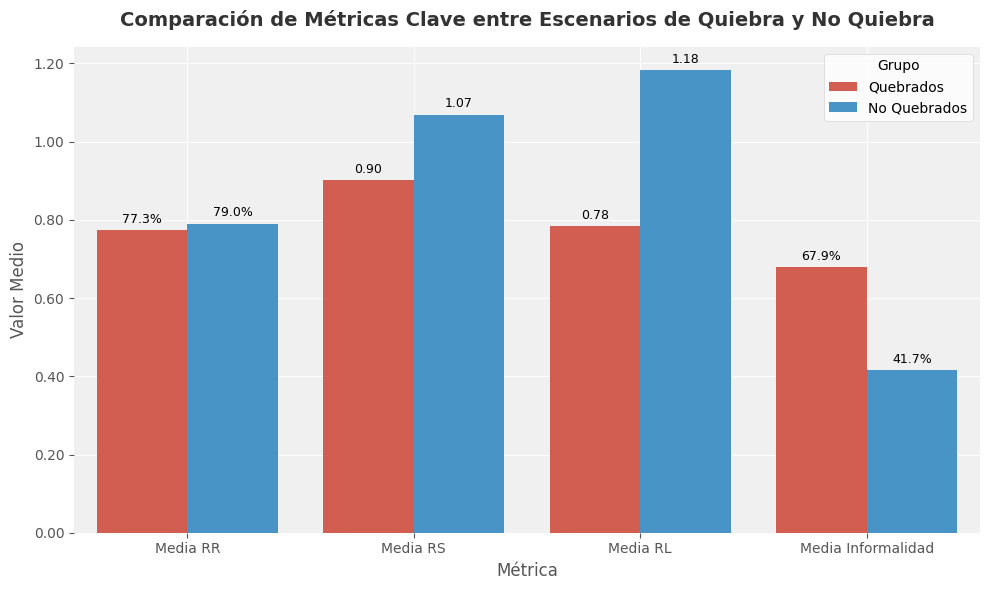

In [ ]:
data_quebrados = {
    'Grupo': 'Quebrados',
    'Media RR': df_quebrados_metrics['RR_mean'].mean(),
    'Media RS': df_quebrados_metrics['RS_mean'].mean(),
    'Media RL': df_quebrados_metrics['RL_mean'].mean(),
    'Media Informalidad': df_quebrados_metrics['infor_mean'].mean()
}
data_no_quebrados = {
    'Grupo': 'No Quebrados',
    'Media RR': df_NOT_quebrados_metrics['RR_mean'].mean(),
    'Media RS': df_NOT_quebrados_metrics['RS_mean'].mean(),
    'Media RL': df_NOT_quebrados_metrics['RL_mean'].mean(),
    'Media Informalidad': df_NOT_quebrados_metrics['infor_mean'].mean()
}

df_comparison = pd.DataFrame([data_quebrados, data_no_quebrados])

df_melted = df_comparison.melt(id_vars='Grupo', var_name='Métrica', value_name='Valor Medio')

plt.style.use('ggplot')
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_facecolor('#f0f0f0')

sns.barplot(
    data=df_melted,
    x='Métrica',
    y='Valor Medio',
    hue='Grupo',
    palette={'Quebrados': '#E74C3C', 'No Quebrados': '#3498DB'},
    ax=ax
)

for container in ax.containers:
    for patch in container.patches:
        value = patch.get_height()
        metric_name = df_melted['Métrica'].unique()[round(patch.get_x() + patch.get_width() / 2)]

        if metric_name == 'Media RR' or metric_name == 'Media Informalidad':
            text = f'{value:.1%}'
        else:
            text = f'{value:.2f}'

        ax.annotate(
            text,
            xy=(patch.get_x() + patch.get_width() / 2, value),
            xytext=(0, 3),
            textcoords='offset points',
            ha='center',
            va='bottom',
            fontsize=9,
            color='black'
        )

ax.set_title('Comparación de Métricas Clave entre Escenarios de Quiebra y No Quiebra',
             fontsize=14, pad=15, fontweight='bold', color='#333333')
ax.set_xlabel('Métrica', fontsize=12, color='#555555')
ax.set_ylabel('Valor Medio', fontsize=12, color='#555555')

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.2f}'))

ax.legend(title='Grupo', frameon=True, facecolor='white')
ax.grid(color='white', linestyle='-', linewidth=0.7)

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.savefig('Comparacion_Metrics_Quebrados_NoQuebrados.png', dpi=300, bbox_inches='tight')
plt.show()